In [1]:
!pip -q install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

print("Everything loaded successfully.")

Everything loaded successfully.


In [3]:
credit = fetch_ucirepo(id=350)

X = credit.data.features.copy()
y = credit.data.targets.copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (30000, 23)
Target shape: (30000, 1)


In [4]:
df = X.copy()

target_name = y.columns[0]
df["DEFAULT"] = y[target_name]

print(df.head())

       X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...    X15    X16    X17  \
0   20000   2   2   1  24   2   2  -1  -1   -2  ...      0      0      0   
1  120000   2   2   2  26  -1   2   0   0    0  ...   3272   3455   3261   
2   90000   2   2   2  34   0   0   0   0    0  ...  14331  14948  15549   
3   50000   2   2   1  37   0   0   0   0    0  ...  28314  28959  29547   
4   50000   1   2   1  57  -1   0  -1   0    0  ...  20940  19146  19131   

    X18    X19    X20   X21   X22   X23  DEFAULT  
0     0    689      0     0     0     0        1  
1     0   1000   1000  1000     0  2000        1  
2  1518   1500   1000  1000  1000  5000        0  
3  2000   2019   1200  1100  1069  1000        0  
4  2000  36681  10000  9000   689   679        0  

[5 rows x 24 columns]


In [5]:
rename_map = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6"
}

df = df.rename(columns=rename_map)

print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst 5 customers:")
display(df.head())

Number of rows: 30000
Number of columns: 24

First 5 customers:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [8]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())
print(missing_values)

Total missing values: 0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64


In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 35


In [10]:
df = df.drop_duplicates().copy()

print("Rows remaining after duplicate removal:", len(df))

Rows remaining after duplicate removal: 29965


In [11]:
df["EDUCATION"] = df["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

df["MARRIAGE"] = df["MARRIAGE"].replace({
    0: 3
})

print("Education categories:", sorted(df["EDUCATION"].unique()))
print("Marriage categories:", sorted(df["MARRIAGE"].unique()))

Education categories: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Marriage categories: [np.int64(1), np.int64(2), np.int64(3)]


In [12]:
default_counts = df["DEFAULT"].value_counts()

print(default_counts)

default_rate = df["DEFAULT"].mean()

print(f"\nOverall default rate: {default_rate:.2%}")

DEFAULT
0    23335
1     6630
Name: count, dtype: int64

Overall default rate: 22.13%


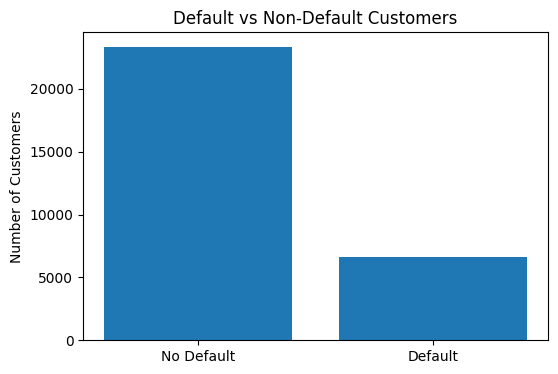

In [13]:
counts = df["DEFAULT"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Default", "Default"], counts.values)

plt.title("Default vs Non-Default Customers")
plt.ylabel("Number of Customers")

plt.show()

AGE_GROUP
21-30    0.224607
31-40    0.204448
41-50    0.232616
51-60    0.252379
61+      0.268382
Name: DEFAULT, dtype: float64


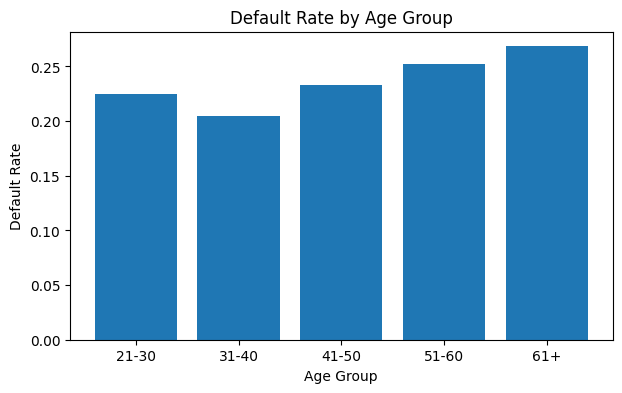

In [14]:
df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[20, 30, 40, 50, 60, 100],
    labels=["21-30", "31-40", "41-50", "51-60", "61+"]
)

age_default = df.groupby("AGE_GROUP", observed=False)["DEFAULT"].mean()

print(age_default)

plt.figure(figsize=(7, 4))
plt.bar(age_default.index.astype(str), age_default.values)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")

plt.show()

PAY_0
-2    0.132364
-1    0.167899
 0    0.128113
 1    0.340333
 2    0.691298
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: DEFAULT, dtype: float64


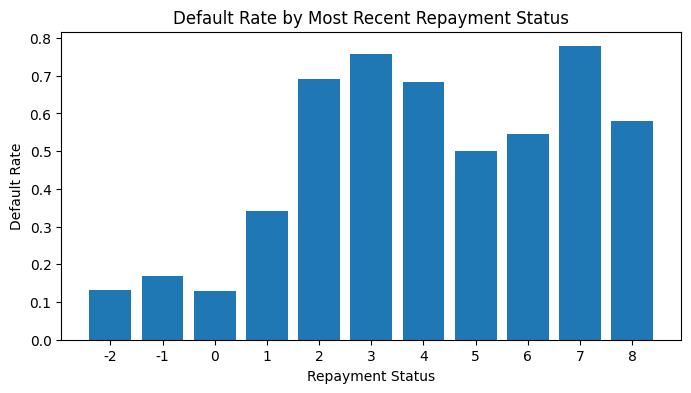

In [15]:
payment_default = df.groupby("PAY_0")["DEFAULT"].mean().sort_index()

print(payment_default)

plt.figure(figsize=(8, 4))
plt.bar(payment_default.index.astype(str), payment_default.values)

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("Repayment Status")
plt.ylabel("Default Rate")

plt.show()

CREDIT_LIMIT_GROUP
(9999.999, 50000.0]      0.317868
(50000.0, 100000.0]      0.258252
(100000.0, 180000.0]     0.198724
(180000.0, 270000.0]     0.168699
(270000.0, 1000000.0]    0.137670
Name: DEFAULT, dtype: float64


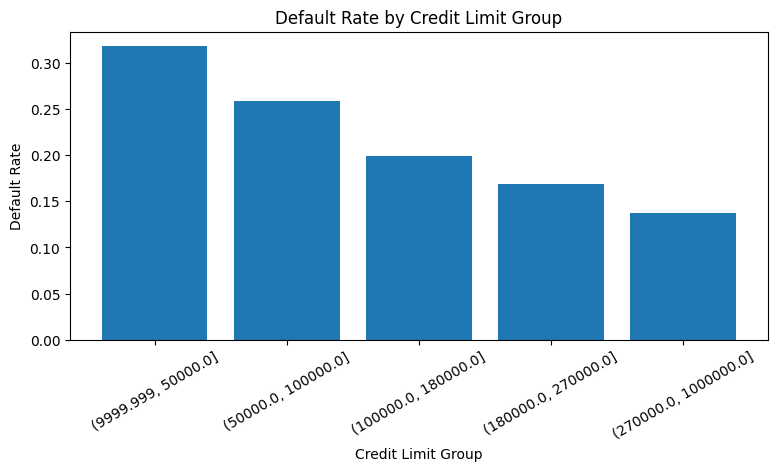

In [16]:
df["CREDIT_LIMIT_GROUP"] = pd.qcut(
    df["LIMIT_BAL"],
    q=5,
    duplicates="drop"
)

limit_default = df.groupby(
    "CREDIT_LIMIT_GROUP",
    observed=False
)["DEFAULT"].mean()

print(limit_default)

plt.figure(figsize=(9, 4))
plt.bar(
    [str(x) for x in limit_default.index],
    limit_default.values
)

plt.title("Default Rate by Credit Limit Group")
plt.xlabel("Credit Limit Group")
plt.ylabel("Default Rate")

plt.xticks(rotation=30)
plt.show()

In [17]:
bill_columns = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

payment_columns = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

repayment_columns = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

df["AVG_BILL"] = df[bill_columns].mean(axis=1)

df["AVG_PAYMENT"] = df[payment_columns].mean(axis=1)

df["MAX_DELAY"] = df[repayment_columns].max(axis=1)

df["MONTHS_DELAYED"] = (df[repayment_columns] > 0).sum(axis=1)

df["UTILISATION"] = (
    df["BILL_AMT1"] / df["LIMIT_BAL"]
).clip(lower=0, upper=5)

print(
    df[
        [
            "AVG_BILL",
            "AVG_PAYMENT",
            "MAX_DELAY",
            "MONTHS_DELAYED",
            "UTILISATION"
        ]
    ].head()
)

       AVG_BILL  AVG_PAYMENT  MAX_DELAY  MONTHS_DELAYED  UTILISATION
0   1284.000000   114.833333          2               2     0.195650
1   2846.166667   833.333333          2               2     0.022350
2  16942.166667  1836.333333          0               0     0.324878
3  38555.666667  1398.000000          0               0     0.939800
4  18223.166667  9841.500000          0               0     0.172340


In [18]:
model_features = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
    "AVG_BILL",
    "AVG_PAYMENT",
    "MAX_DELAY",
    "MONTHS_DELAYED",
    "UTILISATION"
]

X_model = df[model_features]

y_model = df["DEFAULT"]

print("X shape:", X_model.shape)
print("y shape:", y_model.shape)

X shape: (29965, 28)
y shape: (29965,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))

Training customers: 23972
Testing customers: 5993


In [20]:
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

numeric_features = [
    column
    for column in model_features
    if column not in categorical_features
]

print("Categorical:")
print(categorical_features)

print("\nNumeric:")
print(numeric_features)

Categorical:
['SEX', 'EDUCATION', 'MARRIAGE']

Numeric:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_BILL', 'AVG_PAYMENT', 'MAX_DELAY', 'MONTHS_DELAYED', 'UTILISATION']


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [22]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


In [23]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_leaf=5,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained.")

Random Forest trained.


In [24]:
log_pred = logistic_model.predict(X_test)
log_prob = logistic_model.predict_proba(X_test)[:, 1]

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions created.")

Predictions created.


In [25]:
def evaluate_model(name, actual, predicted, probabilities):

    accuracy = accuracy_score(actual, predicted)
    precision = precision_score(actual, predicted)
    recall = recall_score(actual, predicted)
    f1 = f1_score(actual, predicted)
    auc = roc_auc_score(actual, probabilities)

    print(name)
    print("-" * 40)
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print(f"ROC-AUC:   {auc:.3f}")
    print()


evaluate_model(
    "LOGISTIC REGRESSION",
    y_test,
    log_pred,
    log_prob
)

evaluate_model(
    "RANDOM FOREST",
    y_test,
    rf_pred,
    rf_prob
)

LOGISTIC REGRESSION
----------------------------------------
Accuracy:  0.745
Precision: 0.444
Recall:    0.606
F1 Score:  0.512
ROC-AUC:   0.754

RANDOM FOREST
----------------------------------------
Accuracy:  0.778
Precision: 0.498
Recall:    0.582
F1 Score:  0.537
ROC-AUC:   0.775



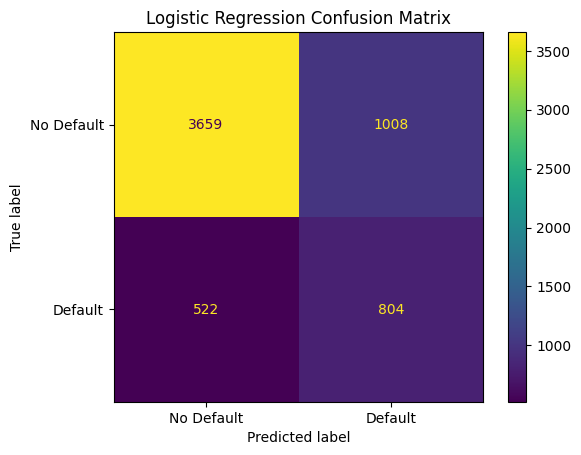

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred,
    display_labels=["No Default", "Default"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

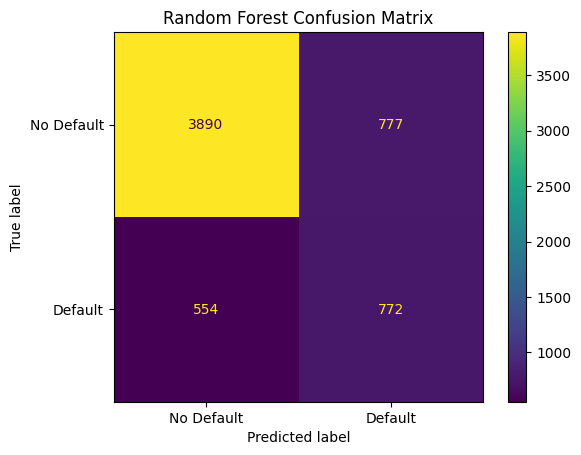

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["No Default", "Default"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [28]:
log_cm = confusion_matrix(y_test, log_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("Logistic Regression:")
print(log_cm)

print("\nRandom Forest:")
print(rf_cm)

Logistic Regression:
[[3659 1008]
 [ 522  804]]

Random Forest:
[[3890  777]
 [ 554  772]]


<Figure size 800x600 with 0 Axes>

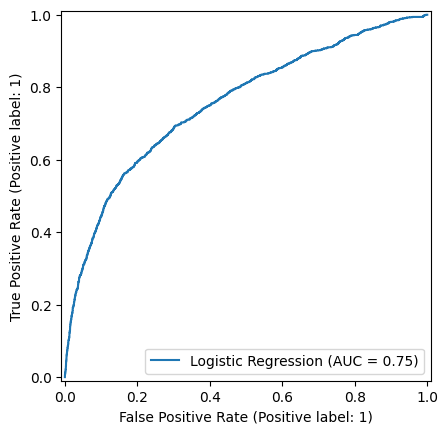

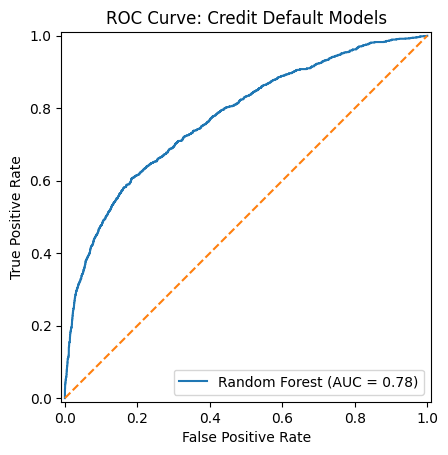

In [29]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    log_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve: Credit Default Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [30]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.Series(
    rf_classifier.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feature_importance.head(15))

numeric__PAY_0             0.135781
numeric__MAX_DELAY         0.129238
numeric__MONTHS_DELAYED    0.121828
numeric__PAY_2             0.051669
numeric__AVG_PAYMENT       0.041075
numeric__UTILISATION       0.038734
numeric__PAY_3             0.035423
numeric__LIMIT_BAL         0.032998
numeric__AVG_BILL          0.032196
numeric__BILL_AMT1         0.029816
numeric__PAY_AMT1          0.028718
numeric__PAY_AMT2          0.027543
numeric__PAY_4             0.026916
numeric__PAY_AMT3          0.024232
numeric__BILL_AMT2         0.024099
dtype: float64


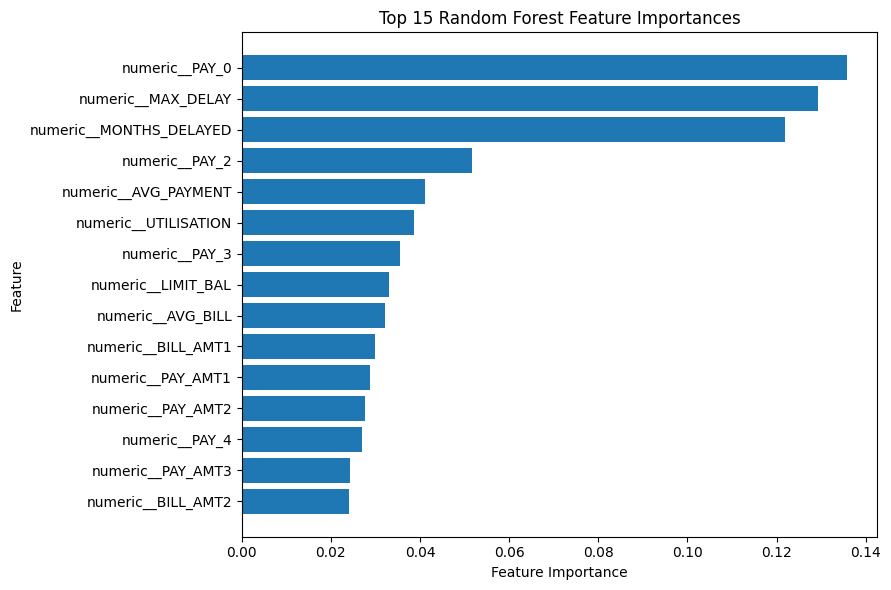

In [31]:
top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_features.index, top_features.values)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [32]:
risk_results = X_test.copy()

risk_results["ACTUAL_DEFAULT"] = y_test.values
risk_results["PREDICTED_DEFAULT_PROBABILITY"] = rf_prob

display(
    risk_results[
        [
            "LIMIT_BAL",
            "AGE",
            "PAY_0",
            "MONTHS_DELAYED",
            "UTILISATION",
            "PREDICTED_DEFAULT_PROBABILITY",
            "ACTUAL_DEFAULT"
        ]
    ].head(10)
)

,LIMIT_BAL,AGE,PAY_0,MONTHS_DELAYED,UTILISATION,PREDICTED_DEFAULT_PROBABILITY,ACTUAL_DEFAULT
8687,50000,43,0,0,0.783540,0.336125,0
24201,240000,31,0,0,0.701567,0.177347,0
27782,90000,25,0,0,0.067667,0.309435,0
14947,50000,22,0,1,0.612620,0.430302,0
1486,230000,32,0,0,0.194496,0.100135,0
1139,230000,47,0,0,0.640435,0.166469,0
26480,30000,59,0,0,0.920667,0.357923,0
27745,290000,24,0,0,0.038472,0.245512,0
1071,150000,44,-1,0,0.002600,0.217558,1
6992,420000,36,-2,0,0.000000,0.207498,0


In [33]:
risk_results["RISK_BAND"] = pd.cut(
    risk_results["PREDICTED_DEFAULT_PROBABILITY"],
    bins=[0, 0.20, 0.40, 0.60, 0.80, 1.00],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    include_lowest=True
)

risk_band_summary = (
    risk_results
    .groupby("RISK_BAND", observed=False)
    .agg(
        Customers=("ACTUAL_DEFAULT", "count"),
        Actual_Default_Rate=("ACTUAL_DEFAULT", "mean"),
        Average_Predicted_Risk=("PREDICTED_DEFAULT_PROBABILITY", "mean")
    )
)

display(risk_band_summary)

,Customers,Actual_Default_Rate,Average_Predicted_Risk
RISK_BAND,,,
Very Low,1099,0.054595,0.159255
Low,2629,0.134652,0.295032
Medium,1105,0.234389,0.482179
High,650,0.426154,0.697766
Very High,510,0.737255,0.862076


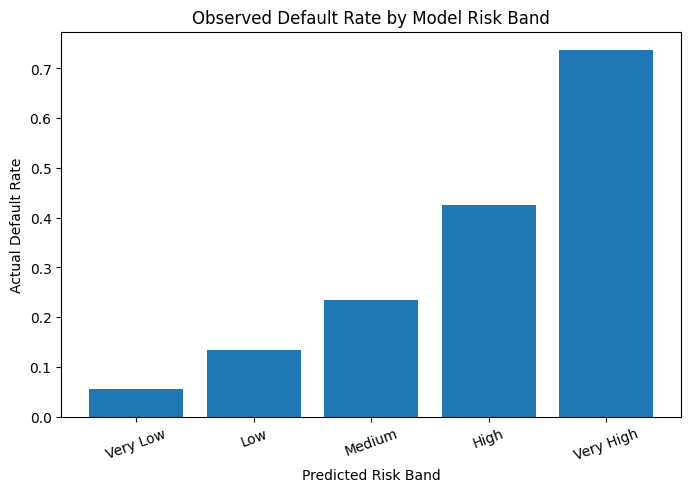

In [34]:
risk_band_plot = risk_band_summary["Actual_Default_Rate"]

plt.figure(figsize=(8, 5))
plt.bar(
    risk_band_plot.index.astype(str),
    risk_band_plot.values
)

plt.title("Observed Default Rate by Model Risk Band")
plt.xlabel("Predicted Risk Band")
plt.ylabel("Actual Default Rate")

plt.xticks(rotation=20)
plt.show()

In [35]:
def recalculate_engineered_features(data):

    stressed = data.copy()

    bill_cols = [
        "BILL_AMT1",
        "BILL_AMT2",
        "BILL_AMT3",
        "BILL_AMT4",
        "BILL_AMT5",
        "BILL_AMT6"
    ]

    payment_cols = [
        "PAY_AMT1",
        "PAY_AMT2",
        "PAY_AMT3",
        "PAY_AMT4",
        "PAY_AMT5",
        "PAY_AMT6"
    ]

    repayment_cols = [
        "PAY_0",
        "PAY_2",
        "PAY_3",
        "PAY_4",
        "PAY_5",
        "PAY_6"
    ]

    stressed["AVG_BILL"] = stressed[bill_cols].mean(axis=1)

    stressed["AVG_PAYMENT"] = stressed[payment_cols].mean(axis=1)

    stressed["MAX_DELAY"] = stressed[repayment_cols].max(axis=1)

    stressed["MONTHS_DELAYED"] = (
        stressed[repayment_cols] > 0
    ).sum(axis=1)

    stressed["UTILISATION"] = (
        stressed["BILL_AMT1"] /
        stressed["LIMIT_BAL"]
    ).clip(lower=0, upper=5)

    return stressed


print("Stress-test function created.")

Stress-test function created.


In [36]:
base_case = X_test.copy()

moderate_stress = X_test.copy()

severe_stress = X_test.copy()

In [37]:
payment_cols = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

moderate_stress[payment_cols] = (
    moderate_stress[payment_cols] * 0.90
)

moderate_stress[bill_cols] = (
    moderate_stress[bill_cols] * 1.05
)

moderate_stress["PAY_0"] = (
    moderate_stress["PAY_0"] + 1
).clip(upper=8)

moderate_stress = recalculate_engineered_features(
    moderate_stress
)

print("Moderate stress scenario created.")

Moderate stress scenario created.


In [38]:
severe_stress[payment_cols] = (
    severe_stress[payment_cols] * 0.75
)

severe_stress[bill_cols] = (
    severe_stress[bill_cols] * 1.10
)

severe_stress["PAY_0"] = (
    severe_stress["PAY_0"] + 2
).clip(upper=8)

severe_stress["PAY_2"] = (
    severe_stress["PAY_2"] + 1
).clip(upper=8)

severe_stress = recalculate_engineered_features(
    severe_stress
)

print("Severe stress scenario created.")

Severe stress scenario created.


In [39]:
base_probability = random_forest_model.predict_proba(
    base_case
)[:, 1]

moderate_probability = random_forest_model.predict_proba(
    moderate_stress
)[:, 1]

severe_probability = random_forest_model.predict_proba(
    severe_stress
)[:, 1]

In [40]:
scenario_results = pd.DataFrame({
    "Scenario": [
        "Base Case",
        "Moderate Stress",
        "Severe Stress"
    ],
    "Average Predicted Default Risk": [
        base_probability.mean(),
        moderate_probability.mean(),
        severe_probability.mean()
    ]
})

display(scenario_results)

,Scenario,Average Predicted Default Risk
0,Base Case,0.396575
1,Moderate Stress,0.490892
2,Severe Stress,0.661843


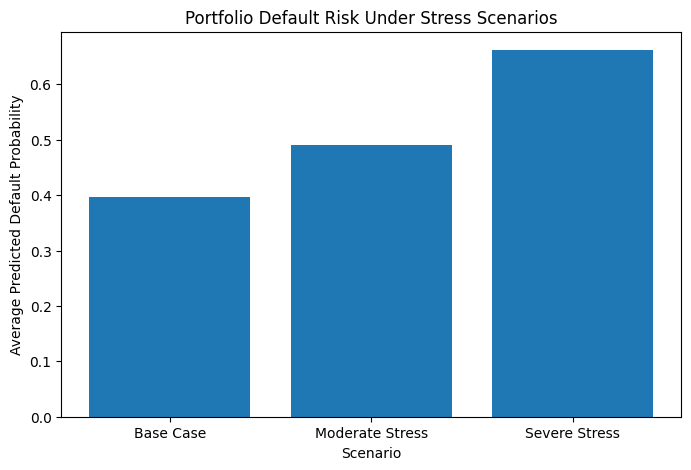

In [41]:
plt.figure(figsize=(8, 5))

plt.bar(
    scenario_results["Scenario"],
    scenario_results["Average Predicted Default Risk"]
)

plt.title("Portfolio Default Risk Under Stress Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Average Predicted Default Probability")

plt.show()

In [42]:
base_risk = base_probability.mean()
moderate_risk = moderate_probability.mean()
severe_risk = severe_probability.mean()

moderate_increase = (
    (moderate_risk - base_risk) / base_risk
) * 100

severe_increase = (
    (severe_risk - base_risk) / base_risk
) * 100

print(f"Base predicted risk: {base_risk:.2%}")
print(f"Moderate stress risk: {moderate_risk:.2%}")
print(f"Severe stress risk: {severe_risk:.2%}")

print(
    f"\nIncrease under moderate stress: "
    f"{moderate_increase:.1f}%"
)

print(
    f"Increase under severe stress: "
    f"{severe_increase:.1f}%"
)

Base predicted risk: 39.66%
Moderate stress risk: 49.09%
Severe stress risk: 66.18%

Increase under moderate stress: 23.8%
Increase under severe stress: 66.9%


In [43]:
results_log = """
CREDIT DEFAULT PREDICTION & STRESS TESTING ENGINE
=================================================

MODEL PERFORMANCE

Logistic Regression
Accuracy:  0.745
Precision: 0.444
Recall:    0.606
F1 Score:  0.512
ROC-AUC:   0.754

Random Forest
Accuracy:  0.778
Precision: 0.498
Recall:    0.582
F1 Score:  0.537
ROC-AUC:   0.775


CONFUSION MATRICES

Logistic Regression
True Negatives: 3659
False Positives: 1008
False Negatives: 522
True Positives: 804

Random Forest
True Negatives: 3890
False Positives: 777
False Negatives: 554
True Positives: 772


TOP RANDOM FOREST FEATURES

PAY_0:          0.135781
MAX_DELAY:      0.129238
MONTHS_DELAYED: 0.121828
PAY_2:          0.051669
AVG_PAYMENT:    0.041075
UTILISATION:    0.038734
PAY_3:          0.035423
LIMIT_BAL:      0.032998
AVG_BILL:       0.032196
BILL_AMT1:      0.029816
PAY_AMT1:       0.028718
PAY_AMT2:       0.027543
PAY_4:          0.026916
PAY_AMT3:       0.024232
BILL_AMT2:      0.024099


INITIAL UNCALIBRATED STRESS TEST

Base:            39.66%
Moderate stress: 49.09%
Severe stress:   66.18%

Relative increase under moderate stress: 23.8%
Relative increase under severe stress:   66.9%

IMPORTANT:
These initial stress probabilities came from the class-weighted
Random Forest and should be treated as model risk scores until
probability calibration is completed.
"""

print(results_log)


CREDIT DEFAULT PREDICTION & STRESS TESTING ENGINE

MODEL PERFORMANCE

Logistic Regression
Accuracy:  0.745
Precision: 0.444
Recall:    0.606
F1 Score:  0.512
ROC-AUC:   0.754

Random Forest
Accuracy:  0.778
Precision: 0.498
Recall:    0.582
F1 Score:  0.537
ROC-AUC:   0.775


CONFUSION MATRICES

Logistic Regression
True Negatives: 3659
False Positives: 1008
False Negatives: 522
True Positives: 804

Random Forest
True Negatives: 3890
False Positives: 777
False Negatives: 554
True Positives: 772


TOP RANDOM FOREST FEATURES

PAY_0:          0.135781
MAX_DELAY:      0.129238
MONTHS_DELAYED: 0.121828
PAY_2:          0.051669
AVG_PAYMENT:    0.041075
UTILISATION:    0.038734
PAY_3:          0.035423
LIMIT_BAL:      0.032998
AVG_BILL:       0.032196
BILL_AMT1:      0.029816
PAY_AMT1:       0.028718
PAY_AMT2:       0.027543
PAY_4:          0.026916
PAY_AMT3:       0.024232
BILL_AMT2:      0.024099


INITIAL UNCALIBRATED STRESS TEST

Base:            39.66%
Moderate stress: 49.09%
Severe stre

In [44]:
feature_importance_table = (
    feature_importance
    .head(15)
    .reset_index()
)

feature_importance_table.columns = [
    "Feature",
    "Importance"
]

feature_importance_table.to_csv(
    "top_15_feature_importance.csv",
    index=False
)

display(feature_importance_table)

print("\nSAVED: top_15_feature_importance.csv")

,Feature,Importance
0,numeric__PAY_0,0.135781
1,numeric__MAX_DELAY,0.129238
2,numeric__MONTHS_DELAYED,0.121828
3,numeric__PAY_2,0.051669
4,numeric__AVG_PAYMENT,0.041075
5,numeric__UTILISATION,0.038734
6,numeric__PAY_3,0.035423
7,numeric__LIMIT_BAL,0.032998
8,numeric__AVG_BILL,0.032196
9,numeric__BILL_AMT1,0.029816



SAVED: top_15_feature_importance.csv


In [45]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf = CalibratedClassifierCV(
    random_forest_model,
    method="sigmoid",
    cv=5
)

print("Starting probability calibration...")

calibrated_rf.fit(
    X_train,
    y_train
)

print("Probability calibration complete.")

Starting probability calibration...
Probability calibration complete.


In [46]:
calibrated_prob = calibrated_rf.predict_proba(
    X_test
)[:, 1]

actual_default_rate = y_test.mean()
uncalibrated_average = rf_prob.mean()
calibrated_average = calibrated_prob.mean()

print(
    f"Actual default rate in test data: "
    f"{actual_default_rate:.2%}"
)

print(
    f"Uncalibrated RF average probability: "
    f"{uncalibrated_average:.2%}"
)

print(
    f"Calibrated RF average probability: "
    f"{calibrated_average:.2%}"
)

Actual default rate in test data: 22.13%
Uncalibrated RF average probability: 39.66%
Calibrated RF average probability: 22.08%


In [47]:
results_log += f"""

PROBABILITY CALIBRATION
=======================

Actual default rate in test data: {actual_default_rate:.2%}
Uncalibrated RF average probability: {uncalibrated_average:.2%}
Calibrated RF average probability: {calibrated_average:.2%}

Interpretation:
The class-weighted Random Forest produced inflated raw probability
scores at portfolio level. Sigmoid calibration brought the average
predicted probability close to the observed test-set default rate.
"""

with open("project_results.txt", "w") as file:
    file.write(results_log)

print(results_log)

print("\nSAVED: project_results.txt")


CREDIT DEFAULT PREDICTION & STRESS TESTING ENGINE

MODEL PERFORMANCE

Logistic Regression
Accuracy:  0.745
Precision: 0.444
Recall:    0.606
F1 Score:  0.512
ROC-AUC:   0.754

Random Forest
Accuracy:  0.778
Precision: 0.498
Recall:    0.582
F1 Score:  0.537
ROC-AUC:   0.775


CONFUSION MATRICES

Logistic Regression
True Negatives: 3659
False Positives: 1008
False Negatives: 522
True Positives: 804

Random Forest
True Negatives: 3890
False Positives: 777
False Negatives: 554
True Positives: 772


TOP RANDOM FOREST FEATURES

PAY_0:          0.135781
MAX_DELAY:      0.129238
MONTHS_DELAYED: 0.121828
PAY_2:          0.051669
AVG_PAYMENT:    0.041075
UTILISATION:    0.038734
PAY_3:          0.035423
LIMIT_BAL:      0.032998
AVG_BILL:       0.032196
BILL_AMT1:      0.029816
PAY_AMT1:       0.028718
PAY_AMT2:       0.027543
PAY_4:          0.026916
PAY_AMT3:       0.024232
BILL_AMT2:      0.024099


INITIAL UNCALIBRATED STRESS TEST

Base:            39.66%
Moderate stress: 49.09%
Severe stre

In [48]:
from sklearn.metrics import brier_score_loss

uncalibrated_brier = brier_score_loss(
    y_test,
    rf_prob
)

calibrated_brier = brier_score_loss(
    y_test,
    calibrated_prob
)

print(
    f"Uncalibrated Random Forest Brier Score: "
    f"{uncalibrated_brier:.4f}"
)

print(
    f"Calibrated Random Forest Brier Score: "
    f"{calibrated_brier:.4f}"
)

Uncalibrated Random Forest Brier Score: 0.1696
Calibrated Random Forest Brier Score: 0.1362


In [49]:
from sklearn.metrics import brier_score_loss

uncalibrated_brier = brier_score_loss(
    y_test,
    rf_prob
)

calibrated_brier = brier_score_loss(
    y_test,
    calibrated_prob
)

print(
    f"Uncalibrated Random Forest Brier Score: "
    f"{uncalibrated_brier:.4f}"
)

print(
    f"Calibrated Random Forest Brier Score: "
    f"{calibrated_brier:.4f}"
)

Uncalibrated Random Forest Brier Score: 0.1696
Calibrated Random Forest Brier Score: 0.1362


<Figure size 800x600 with 0 Axes>

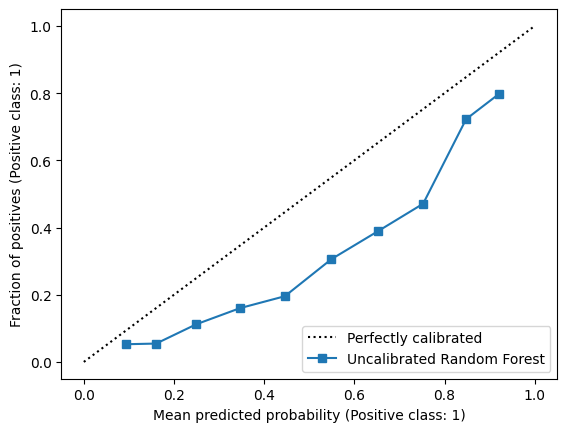

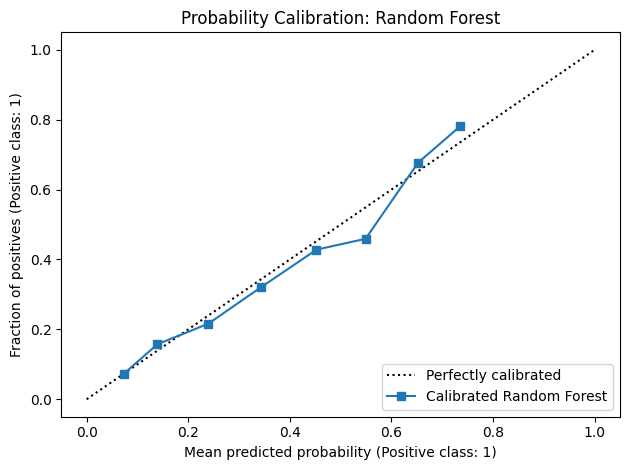

SAVED: probability_calibration.png


In [50]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_test,
    rf_prob,
    n_bins=10,
    name="Uncalibrated Random Forest"
)

CalibrationDisplay.from_predictions(
    y_test,
    calibrated_prob,
    n_bins=10,
    name="Calibrated Random Forest"
)

plt.title("Probability Calibration: Random Forest")
plt.tight_layout()

plt.savefig(
    "probability_calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SAVED: probability_calibration.png")

In [51]:
results_log += f"""

CALIBRATION QUALITY
===================

Uncalibrated RF Brier Score: {uncalibrated_brier:.4f}
Calibrated RF Brier Score: {calibrated_brier:.4f}

Note:
Lower Brier Score indicates better probabilistic accuracy.
"""

with open("project_results.txt", "w") as file:
    file.write(results_log)

print("Calibration results added to project_results.txt")

Calibration results added to project_results.txt


In [52]:
calibrated_base_probability = calibrated_rf.predict_proba(
    base_case
)[:, 1]

calibrated_moderate_probability = calibrated_rf.predict_proba(
    moderate_stress
)[:, 1]

calibrated_severe_probability = calibrated_rf.predict_proba(
    severe_stress
)[:, 1]

print("Calibrated stress-test predictions created.")

Calibrated stress-test predictions created.


In [53]:
final_base_risk = calibrated_base_probability.mean()

final_moderate_risk = calibrated_moderate_probability.mean()

final_severe_risk = calibrated_severe_probability.mean()


final_moderate_increase = (
    (final_moderate_risk - final_base_risk)
    / final_base_risk
) * 100

final_severe_increase = (
    (final_severe_risk - final_base_risk)
    / final_base_risk
) * 100


print(
    f"BASE CASE: "
    f"{final_base_risk:.2%}"
)

print(
    f"MODERATE STRESS: "
    f"{final_moderate_risk:.2%}"
)

print(
    f"SEVERE STRESS: "
    f"{final_severe_risk:.2%}"
)

print(
    f"\nRelative increase under moderate stress: "
    f"{final_moderate_increase:.1f}%"
)

print(
    f"Relative increase under severe stress: "
    f"{final_severe_increase:.1f}%"
)

BASE CASE: 22.08%
MODERATE STRESS: 28.31%
SEVERE STRESS: 47.17%

Relative increase under moderate stress: 28.2%
Relative increase under severe stress: 113.7%


In [54]:
final_scenario_results = pd.DataFrame({
    "Scenario": [
        "Base Case",
        "Moderate Stress",
        "Severe Stress"
    ],
    "Average_Predicted_Default_Probability": [
        final_base_risk,
        final_moderate_risk,
        final_severe_risk
    ]
})

display(final_scenario_results)

final_scenario_results.to_csv(
    "final_stress_test_results.csv",
    index=False
)

print("\nSAVED: final_stress_test_results.csv")

,Scenario,Average_Predicted_Default_Probability
0,Base Case,0.220770
1,Moderate Stress,0.283126
2,Severe Stress,0.471689



SAVED: final_stress_test_results.csv


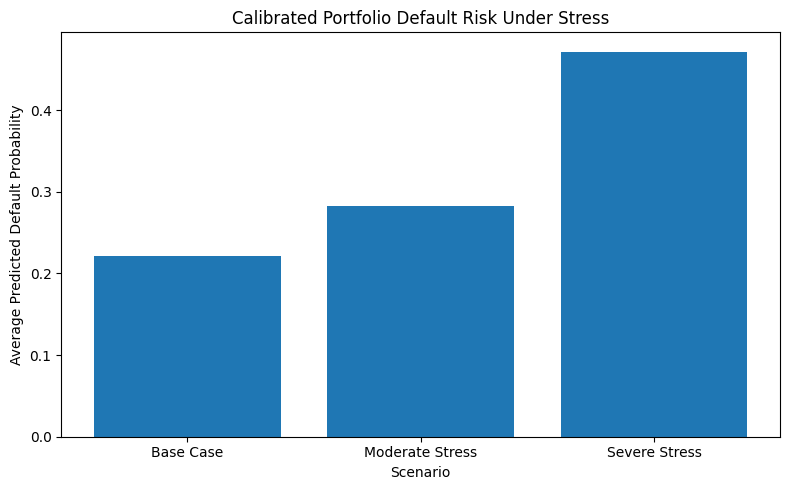

SAVED: calibrated_stress_test.png


In [55]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_scenario_results["Scenario"],
    final_scenario_results[
        "Average_Predicted_Default_Probability"
    ]
)

plt.title(
    "Calibrated Portfolio Default Risk Under Stress"
)

plt.xlabel("Scenario")
plt.ylabel("Average Predicted Default Probability")

plt.tight_layout()

plt.savefig(
    "calibrated_stress_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SAVED: calibrated_stress_test.png")

In [56]:
results_log += f"""

FINAL CALIBRATED STRESS TEST
============================

Base Case: {final_base_risk:.2%}
Moderate Stress: {final_moderate_risk:.2%}
Severe Stress: {final_severe_risk:.2%}

Relative Increase Under Moderate Stress:
{final_moderate_increase:.1f}%

Relative Increase Under Severe Stress:
{final_severe_increase:.1f}%

Scenario assumptions:

Moderate Stress:
- Customer payments reduced by 10%
- Outstanding bill amounts increased by 5%
- Most recent repayment status deteriorated by one level

Severe Stress:
- Customer payments reduced by 25%
- Outstanding bill amounts increased by 10%
- Recent repayment behaviour deteriorated more substantially

IMPORTANT:
These scenarios are illustrative behavioural stress scenarios,
not regulatory forecasts or Bank of England stress-test scenarios.
"""

with open("project_results.txt", "w") as file:
    file.write(results_log)

print("FINAL STRESS RESULTS SAVED TO project_results.txt")

FINAL STRESS RESULTS SAVED TO project_results.txt


In [57]:
calibrated_risk_results = X_test.copy()

calibrated_risk_results["ACTUAL_DEFAULT"] = y_test.values

calibrated_risk_results[
    "PREDICTED_DEFAULT_PROBABILITY"
] = calibrated_prob


calibrated_risk_results["RISK_BAND"] = pd.qcut(
    calibrated_risk_results[
        "PREDICTED_DEFAULT_PROBABILITY"
    ],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)


risk_band_summary = (
    calibrated_risk_results
    .groupby("RISK_BAND", observed=False)
    .agg(
        Customers=("ACTUAL_DEFAULT", "count"),
        Average_Predicted_Risk=(
            "PREDICTED_DEFAULT_PROBABILITY",
            "mean"
        ),
        Actual_Default_Rate=(
            "ACTUAL_DEFAULT",
            "mean"
        )
    )
)

display(risk_band_summary)

,Customers,Average_Predicted_Risk,Actual_Default_Rate
RISK_BAND,,,
Very Low,1199,0.062855,0.060884
Low,1198,0.093502,0.100167
Medium,1199,0.137039,0.168474
High,1198,0.238489,0.227045
Very High,1199,0.571874,0.549625


In [58]:
risk_band_summary.to_csv(
    "calibrated_risk_band_summary.csv"
)

print("SAVED: calibrated_risk_band_summary.csv")

SAVED: calibrated_risk_band_summary.csv


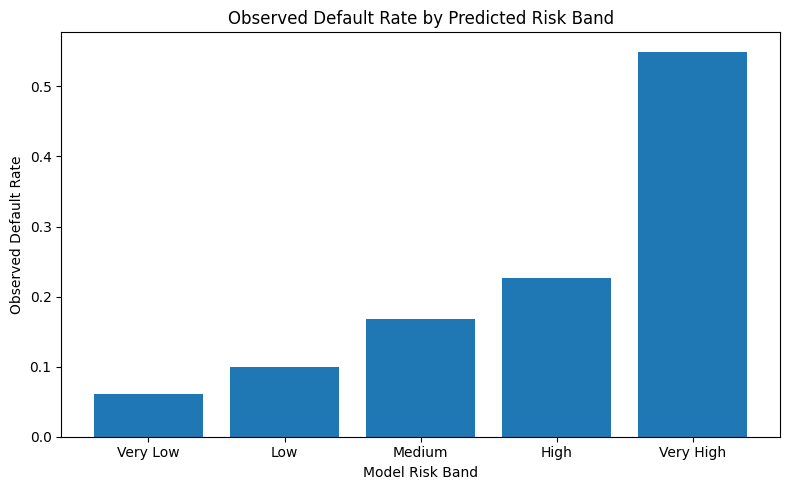

SAVED: observed_default_by_risk_band.png


In [59]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_band_summary.index.astype(str),
    risk_band_summary["Actual_Default_Rate"]
)

plt.title(
    "Observed Default Rate by Predicted Risk Band"
)

plt.xlabel("Model Risk Band")
plt.ylabel("Observed Default Rate")

plt.tight_layout()

plt.savefig(
    "observed_default_by_risk_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "SAVED: observed_default_by_risk_band.png"
)

In [60]:
high_risk_customers = calibrated_risk_results[
    calibrated_risk_results["RISK_BAND"]
    == "Very High"
]


comparison_variables = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "MAX_DELAY",
    "MONTHS_DELAYED",
    "AVG_BILL",
    "AVG_PAYMENT",
    "UTILISATION"
]


portfolio_average = (
    calibrated_risk_results[
        comparison_variables
    ]
    .mean()
)


high_risk_average = (
    high_risk_customers[
        comparison_variables
    ]
    .mean()
)


high_risk_profile = pd.DataFrame({
    "Portfolio Average": portfolio_average,
    "Very High Risk Average": high_risk_average
})


high_risk_profile[
    "Difference %"
] = (
    (
        high_risk_profile[
            "Very High Risk Average"
        ]
        -
        high_risk_profile[
            "Portfolio Average"
        ]
    )
    /
    high_risk_profile[
        "Portfolio Average"
    ].abs()
) * 100


display(high_risk_profile)

,Portfolio Average,Very High Risk Average,Difference %
LIMIT_BAL,168119.472718,110358.632193,-34.357020
AGE,35.590856,35.663887,0.205195
PAY_0,-0.034874,1.378649,4053.226173
MAX_DELAY,0.435842,2.123436,387.203412
MONTHS_DELAYED,0.839313,3.241868,286.252808
AVG_BILL,44934.293203,41415.019044,-7.832045
AVG_PAYMENT,5290.351772,2108.660133,-60.141400
UTILISATION,0.418972,0.536892,28.145176


In [61]:
high_risk_profile.to_csv(
    "very_high_risk_customer_profile.csv"
)

print(
    "SAVED: very_high_risk_customer_profile.csv"
)

SAVED: very_high_risk_customer_profile.csv


In [62]:
very_high_risk_count = len(
    high_risk_customers
)

very_high_actual_default = (
    high_risk_customers[
        "ACTUAL_DEFAULT"
    ].mean()
)

very_high_predicted_risk = (
    high_risk_customers[
        "PREDICTED_DEFAULT_PROBABILITY"
    ].mean()
)

portfolio_actual_default = (
    calibrated_risk_results[
        "ACTUAL_DEFAULT"
    ].mean()
)


print(
    f"Very High Risk customers: "
    f"{very_high_risk_count}"
)

print(
    f"Very High Risk predicted probability: "
    f"{very_high_predicted_risk:.2%}"
)

print(
    f"Very High Risk actual default rate: "
    f"{very_high_actual_default:.2%}"
)

print(
    f"Whole portfolio actual default rate: "
    f"{portfolio_actual_default:.2%}"
)

Very High Risk customers: 1199
Very High Risk predicted probability: 57.19%
Very High Risk actual default rate: 54.96%
Whole portfolio actual default rate: 22.13%


In [63]:
results_log += f"""

HIGH-RISK SEGMENT
=================

Very High Risk customers: {very_high_risk_count}

Average predicted probability:
{very_high_predicted_risk:.2%}

Observed default rate:
{very_high_actual_default:.2%}

Whole portfolio observed default rate:
{portfolio_actual_default:.2%}
"""

with open("project_results.txt", "w") as file:
    file.write(results_log)

print(
    "HIGH-RISK RESULTS SAVED TO project_results.txt"
)

HIGH-RISK RESULTS SAVED TO project_results.txt


In [64]:
# ==========================================
# HIGH-RISK CONCENTRATION ANALYSIS
# ==========================================

total_defaults = calibrated_risk_results[
    "ACTUAL_DEFAULT"
].sum()

very_high_defaults = high_risk_customers[
    "ACTUAL_DEFAULT"
].sum()

default_capture_rate = (
    very_high_defaults / total_defaults
)

risk_lift = (
    very_high_actual_default /
    portfolio_actual_default
)

print("HIGH-RISK CONCENTRATION")
print("-" * 40)

print(
    f"Total defaults in test portfolio: "
    f"{total_defaults}"
)

print(
    f"Defaults in Very High Risk group: "
    f"{very_high_defaults}"
)

print(
    f"Share of all defaults captured "
    f"by top 20% risk group: "
    f"{default_capture_rate:.2%}"
)

print(
    f"Very High Risk default rate: "
    f"{very_high_actual_default:.2%}"
)

print(
    f"Portfolio default rate: "
    f"{portfolio_actual_default:.2%}"
)

print(
    f"Risk lift: "
    f"{risk_lift:.2f}x"
)

HIGH-RISK CONCENTRATION
----------------------------------------
Total defaults in test portfolio: 1326
Defaults in Very High Risk group: 659
Share of all defaults captured by top 20% risk group: 49.70%
Very High Risk default rate: 54.96%
Portfolio default rate: 22.13%
Risk lift: 2.48x


In [65]:
results_log += f"""

HIGH-RISK CONCENTRATION
=======================

Total defaults in test portfolio:
{total_defaults}

Defaults in Very High Risk group:
{very_high_defaults}

Share of all defaults captured by
the highest-risk 20%:
{default_capture_rate:.2%}

Very High Risk observed default rate:
{very_high_actual_default:.2%}

Whole portfolio observed default rate:
{portfolio_actual_default:.2%}

Risk lift:
{risk_lift:.2f}x
"""

with open("project_results.txt", "w") as file:
    file.write(results_log)

print(
    "HIGH-RISK CONCENTRATION SAVED "
    "TO project_results.txt"
)

HIGH-RISK CONCENTRATION SAVED TO project_results.txt


In [66]:
clean_profile = pd.DataFrame({
    "Metric": [
        "Average Credit Limit",
        "Average Payment",
        "Average Bill",
        "Credit Utilisation",
        "Months Delayed",
        "Worst Delay Status",
        "Recent Repayment Status",
        "Age"
    ],

    "Portfolio": [
        calibrated_risk_results["LIMIT_BAL"].mean(),
        calibrated_risk_results["AVG_PAYMENT"].mean(),
        calibrated_risk_results["AVG_BILL"].mean(),
        calibrated_risk_results["UTILISATION"].mean(),
        calibrated_risk_results["MONTHS_DELAYED"].mean(),
        calibrated_risk_results["MAX_DELAY"].mean(),
        calibrated_risk_results["PAY_0"].mean(),
        calibrated_risk_results["AGE"].mean()
    ],

    "Very High Risk": [
        high_risk_customers["LIMIT_BAL"].mean(),
        high_risk_customers["AVG_PAYMENT"].mean(),
        high_risk_customers["AVG_BILL"].mean(),
        high_risk_customers["UTILISATION"].mean(),
        high_risk_customers["MONTHS_DELAYED"].mean(),
        high_risk_customers["MAX_DELAY"].mean(),
        high_risk_customers["PAY_0"].mean(),
        high_risk_customers["AGE"].mean()
    ]
})

clean_profile["Absolute Difference"] = (
    clean_profile["Very High Risk"]
    - clean_profile["Portfolio"]
)

display(clean_profile.round(3))

clean_profile.to_csv(
    "clean_high_risk_profile.csv",
    index=False
)

print("\nSAVED: clean_high_risk_profile.csv")

,Metric,Portfolio,Very High Risk,Absolute Difference
0,Average Credit Limit,168119.473,110358.632,-57760.841
1,Average Payment,5290.352,2108.660,-3181.692
2,Average Bill,44934.293,41415.019,-3519.274
3,Credit Utilisation,0.419,0.537,0.118
4,Months Delayed,0.839,3.242,2.403
5,Worst Delay Status,0.436,2.123,1.688
6,Recent Repayment Status,-0.035,1.379,1.414
7,Age,35.591,35.664,0.073



SAVED: clean_high_risk_profile.csv


In [67]:
# ==========================================
# COST-SENSITIVE THRESHOLD ANALYSIS
# ==========================================

thresholds = np.arange(
    0.05,
    0.81,
    0.01
)

FALSE_POSITIVE_COST = 1
FALSE_NEGATIVE_COST = 5

threshold_rows = []


for threshold in thresholds:

    predictions = (
        calibrated_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    total_cost = (
        FALSE_POSITIVE_COST * fp
        +
        FALSE_NEGATIVE_COST * fn
    )

    threshold_rows.append({
        "Threshold": threshold,
        "True_Negatives": tn,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Illustrative_Cost": total_cost
    })


threshold_analysis = pd.DataFrame(
    threshold_rows
)

best_row = threshold_analysis.loc[
    threshold_analysis[
        "Illustrative_Cost"
    ].idxmin()
]


print(
    "ILLUSTRATIVE 5:1 COST ASSUMPTION"
)

print("-" * 45)

print(
    f"Selected threshold: "
    f"{best_row['Threshold']:.2f}"
)

print(
    f"Illustrative total cost: "
    f"{best_row['Illustrative_Cost']:.0f}"
)

print(
    f"Accuracy: "
    f"{best_row['Accuracy']:.3f}"
)

print(
    f"Precision: "
    f"{best_row['Precision']:.3f}"
)

print(
    f"Recall: "
    f"{best_row['Recall']:.3f}"
)

print(
    f"F1 Score: "
    f"{best_row['F1']:.3f}"
)

print(
    f"False Positives: "
    f"{best_row['False_Positives']:.0f}"
)

print(
    f"False Negatives: "
    f"{best_row['False_Negatives']:.0f}"
)

ILLUSTRATIVE 5:1 COST ASSUMPTION
---------------------------------------------
Selected threshold: 0.15
Illustrative total cost: 3406
Accuracy: 0.659
Precision: 0.366
Recall: 0.744
F1 Score: 0.491
False Positives: 1706
False Negatives: 340


In [68]:
standard_row = threshold_analysis[
    np.isclose(
        threshold_analysis["Threshold"],
        0.50
    )
].iloc[0]


comparison_table = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positives",
        "False Negatives",
        "Illustrative Cost"
    ],

    "Standard 50%": [
        standard_row["Threshold"],
        standard_row["Accuracy"],
        standard_row["Precision"],
        standard_row["Recall"],
        standard_row["F1"],
        standard_row["False_Positives"],
        standard_row["False_Negatives"],
        standard_row["Illustrative_Cost"]
    ],

    "Cost-Sensitive": [
        best_row["Threshold"],
        best_row["Accuracy"],
        best_row["Precision"],
        best_row["Recall"],
        best_row["F1"],
        best_row["False_Positives"],
        best_row["False_Negatives"],
        best_row["Illustrative_Cost"]
    ]
})


display(
    comparison_table.round(3)
)


comparison_table.to_csv(
    "threshold_comparison.csv",
    index=False
)

threshold_analysis.to_csv(
    "full_threshold_analysis.csv",
    index=False
)


print(
    "\nSAVED: threshold_comparison.csv"
)

print(
    "SAVED: full_threshold_analysis.csv"
)

,Metric,Standard 50%,Cost-Sensitive
0,Threshold,0.500,0.150
1,Accuracy,0.815,0.659
2,Precision,0.638,0.366
3,Recall,0.383,0.744
4,F1 Score,0.479,0.491
5,False Positives,288.000,1706.000
6,False Negatives,818.000,340.000
7,Illustrative Cost,4378.000,3406.000



SAVED: threshold_comparison.csv
SAVED: full_threshold_analysis.csv


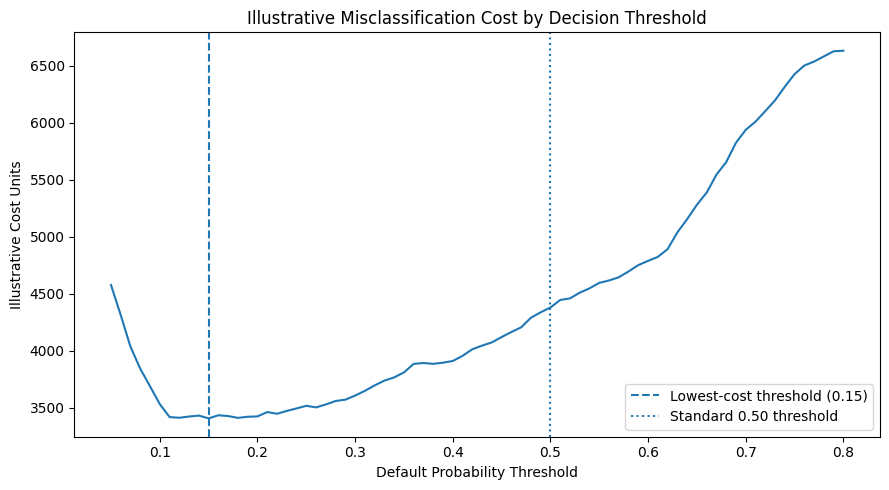

SAVED: threshold_cost_analysis.png


In [69]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_analysis["Threshold"],
    threshold_analysis["Illustrative_Cost"]
)

plt.axvline(
    x=best_row["Threshold"],
    linestyle="--",
    label=(
        f"Lowest-cost threshold "
        f"({best_row['Threshold']:.2f})"
    )
)

plt.axvline(
    x=0.50,
    linestyle=":",
    label="Standard 0.50 threshold"
)

plt.title(
    "Illustrative Misclassification Cost "
    "by Decision Threshold"
)

plt.xlabel(
    "Default Probability Threshold"
)

plt.ylabel(
    "Illustrative Cost Units"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "threshold_cost_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "SAVED: threshold_cost_analysis.png"
)

In [70]:
cost_ratios = [
    2,
    5,
    10
]

sensitivity_results = []


for fn_cost in cost_ratios:

    rows = []

    for threshold in thresholds:

        predictions = (
            calibrated_prob >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            predictions
        ).ravel()

        total_cost = (
            fp
            +
            fn_cost * fn
        )

        rows.append({
            "Threshold": threshold,
            "Cost": total_cost,
            "FP": fp,
            "FN": fn,
            "Recall": recall_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "Precision": precision_score(
                y_test,
                predictions,
                zero_division=0
            )
        })


    temp = pd.DataFrame(rows)

    best = temp.loc[
        temp["Cost"].idxmin()
    ]

    sensitivity_results.append({
        "False_Negative_to_FP_Cost_Ratio":
            f"{fn_cost}:1",

        "Selected_Threshold":
            best["Threshold"],

        "Illustrative_Cost":
            best["Cost"],

        "False_Positives":
            best["FP"],

        "False_Negatives":
            best["FN"],

        "Recall":
            best["Recall"],

        "Precision":
            best["Precision"]
    })


threshold_sensitivity = pd.DataFrame(
    sensitivity_results
)

display(
    threshold_sensitivity.round(3)
)

threshold_sensitivity.to_csv(
    "threshold_cost_sensitivity.csv",
    index=False
)

print(
    "\nSAVED: threshold_cost_sensitivity.csv"
)

,False_Negative_to_FP_Cost_Ratio,Selected_Threshold,Illustrative_Cost,False_Positives,False_Negatives,Recall,Precision
0,2:1,0.40,1839.0,459.0,690.0,0.480,0.581
1,5:1,0.15,3406.0,1706.0,340.0,0.744,0.366
2,10:1,0.07,4247.0,3817.0,43.0,0.968,0.252



SAVED: threshold_cost_sensitivity.csv
